# **Graph instance for Random Walk Interdiction Problem in Cybersecurity**

## **Introduction to Graph Databases with Neo4j**

This notebook relies on Neo4j, a native graph database designed to store, manage, and query highly connected data. Unlike traditional relational databases, Neo4j uses a property graph model (nodes, relationships, and properties) to represent complex data networks intuitively and efficiently.

In this notebook, we will:

- Establish a connection to a Neo4j database using the official Python driver.
- Use Cypher (Neo4j's query language) to create nodes and define relationships.
- Visualize the results of our queries directly within the notebook environment.

### **Documentation Links**
Here are the most useful links to get started:

- Main Neo4j Documentation: https://neo4j.com/docs/
- The Cypher Language Manual (essential): https://neo4j.com/docs/cypher-manual/current/
- Python Driver Documentation (for your notebook): https://neo4j.com/docs/python-manual/current/

### **Installation of Neo4j**

Neo4j is not just a Python library; it also requires installing the core database server as a Linux package. This involves fetching the official security key, adding the Neo4j repository to the system's list of software sources, and then downloading the package itself.

In [2]:
%%bash
NEO4J_VERSION="5.18.0"
if [ ! -d "neo4j_local" ]; then
    wget -q -nc https://neo4j.com/artifact.php?name=neo4j-community-$NEO4J_VERSION-unix.tar.gz -O neo4j.tar.gz
    tar -xzf neo4j.tar.gz
    mv neo4j-community-$NEO4J_VERSION neo4j_local
    rm neo4j.tar.gz
fi
if [ ! -f "neo4j_local/plugins/apoc-$NEO4J_VERSION-core.jar" ]; then
    wget -q -nc https://github.com/neo4j/apoc/releases/download/$NEO4J_VERSION/apoc-$NEO4J_VERSION-core.jar -P neo4j_local/plugins/
fi
CONF_FILE="neo4j_local/conf/neo4j.conf"
APOC_CONF="neo4j_local/conf/apoc.conf"
if ! grep -q "dbms.security.procedures.unrestricted=apoc.\*" "$CONF_FILE"; then
    echo "dbms.security.procedures.unrestricted=apoc.*" >> "$CONF_FILE"
    echo "apoc.export.file.enabled=true" > "$APOC_CONF"
    ./neo4j_local/bin/neo4j-admin dbms set-initial-password "password"
fi
echo "[+] Environnement Neo4j prêt !"

Changed password for user 'neo4j'. IMPORTANT: this change will only take effect if performed before the database is started for the first time.
[+] Environnement Neo4j prêt !


### **Configuration of Neo4j**

Now we move on to the configuration phase. Simply installing the database is not enough to use it within a notebook environment. Because notebooks often execute commands as the root user by default, we need to adjust file permissions and user profiles to satisfy Neo4j's strict security requirements.

This cell handles the necessary housekeeping: it fixes permissions, sets a default password, starts the server under the correct user, and waits for it to be ready.

**Important Note**: If the Neo4j server crashes, disconnects, or becomes unresponsive later on while you are working, you can simply re-run this specific cell to restart it and get everything back on track.

In [ ]:
# 1. Ensure the server is completely stopped to apply our configurations safely.
!sudo neo4j stop

# 2. Assign ownership of all Neo4j directories to the dedicated "neo4j" user.
# For security reasons, Neo4j will refuse to start if its core files are owned
# by the root user instead of the 'neo4j' user.
!sudo chown -R neo4j:neo4j /var/lib/neo4j /var/log/neo4j /etc/neo4j

# 3. Set the initial password to "password" (for Neo4j v5+).
# Setting a known initial password programmatically saves us from having to open
# a web interface to complete the setup interactively.
!sudo -u neo4j neo4j-admin dbms set-initial-password "password"

# 4. Start the Neo4j server using the correct user profile.
!sudo -u neo4j neo4j start

# 5. Wait for port 7687 to become active.
# The 'nc' (netcat) command checks if the Bolt port (7687), which Python uses to
# communicate with Neo4j, is officially open.
!echo "[*] Waiting for Neo4j to wake up..."
!while ! nc -z localhost 7687; do sleep 2; echo -n "."; done; echo -e "\n[+] Neo4j is online and ready!"

## **Configuration of the Notebook's Environment**

In the next section, we will set up our Python environment. First, we will clone the AdSimulator repository and ensure it is properly configured. Next,  we will mount our Google Drive to access the custom Python files that contain all our required methods. Finally, we will install the remaining Python dependencies using pip.

In [ ]:
# --- Neo4j Python Driver ---

!pip install neo4j

# --- AdSimulator Setup ---

# Clone the AdSimulator repository from GitHub.
!git clone https://github.com/nicolas-carolo/adsimulator.git
%cd adsimulator

# Execute the custom Linux installation script provided by the repository.
!./installer_linux.sh

# Install all the required Python dependencies listed in the repository.
!pip install -r requirements.txt

# Install AdSimulator itself as a recognizable Python package in our environment.
!python setup.py install

# Navigate back to the parent directory to keep our workspace organized.
%cd ..

# Create the target hidden directory in the root folder.
# AdSimulator expects its default datasets to be located in a specific hidden path.
!mkdir -p /root/.adsimulator/data/
!cp -r /content/adsimulator/data/* /root/.adsimulator/data/

In [18]:
import sys
from google.colab import drive

# Mount Google Drive to access personal files.
drive.mount('/content/drive', force_remount=True)

# IMPORTANT : Define the exact path to YOUR working directory.
project_folder = "/content/drive/MyDrive/ADS Colab's"

# Tell Python to add this folder to its search path, prioritizing it.
if project_folder not in sys.path:
    sys.path.insert(0, project_folder) # Use insert(0) to give it highest priority

print(f"[*] sys.path after modification: {sys.path}")

# We can now import our required modules from this folder.
import utils

Mounted at /content/drive
[*] sys.path after modification: ["/content/drive/MyDrive/ADS Colab's", '/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython']


In [19]:
# Imports

import os
import json
import random
import networkx as nx
import numpy as np
import subprocess
import time
from neo4j import GraphDatabase
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

**Important Note**: Run the cell below every time you modify the utils_notebook.py file while the notebook is open.

In [22]:
import importlib
import utils

# Force Python to clear the old cache and reload the file
importlib.reload(utils)

<module 'utils' from "/content/drive/MyDrive/ADS Colab's/utils.py">

## **Random Walk Interdiction Problem in Cybersecurity**

This notebook aims to propose a solution for generating graphs intended for cyberattack modeling.

### **Example 1: Building the default graph**

For the construction of the default graph, we tried to create the simplest possible graph that AdSimulator would allow. However, as we can see, it is far from simple, and the visualization of the graph doesn't really help.

The reason the graph is so complicated is that it contains a lot of default nodes. The idea is that when using Windows, user accounts are automatically created (e.g., Guest, Admin, etc.). Similarly, we are required to have a computer to host the AD server. And that is without even mentioning the groups.

Areas for improvement:
- Brainstorm a better way to represent the AD.
- Remove the default nodes?
- Remove nodes that provide no useful information?

In [24]:
# Modifiez ce chemin selon où se trouve l'exécutable/script adsimulator dans Colab
AD_PATH = "adsimulator"

utils.run_pipeline(0, AD_PATH)

print("\n[+] GÉNÉRATION TERMINÉE ! Toutes les matrices sont prêtes.")


[*] Lancement du pipeline pour l'Instance 0
[+] Config générée : adsimulator_config_0.json
--- LOGS ADSIMULATOR ---


      ,.,
      MMMM_    ,..,
        "_ "__"MMMMM          ,...,,
 ,..., __." --"    ,.,     _-"MMMMMMM
MMMMMM"___ "_._   MMM"_."" _          _     _                 _       _               
 """""    "" , \_.   "_. ."  __ _  __| |___(_)_ __ ___  _   _| | __ _| |_ ___  _ __    
        ,., _"__ \__./ ."   / _` |/ _` / __| | '_ ` _ \| | | | |/ _` | __/ _ \| '__|   
       MMMMM_"  "_    ./   | (_| | (_| \__ \ | | | | | | |_| | | (_| | || (_) | | 
        ''''      (    )    \__,_|\__,_|___/_|_| |_| |_|\__,_|_|\__,_|\__\___/|_|  
 ._______________.-'____"---._.
  \                          /
   \________________________/
   (_)                    (_)

                                                         
                                                          
        
 A realistic simulator of Active Directory domains


Documented commands (type help <topic>):
ab

In [ ]:
utils.plot_ad_complete_graph('/tmp/export.json')

### **Minimum number of users**

Despite our request (by default) to create only 5 users, we can see on the graph above that there are actually 9. This is perfectly normal, as there are 4 user accounts created by default on Windows, in addition to the user accounts assigned to actual people:
- Guest
- Default Account
- Admin
- KRBTGT

In [23]:

compteur = 0
with open('/tmp/export.json', 'r', encoding='utf-8') as f:
    for line in f:
        if not line.strip():
            continue

        data = json.loads(line)

        # On cherche uniquement les nœuds de type "User"
        if data.get('type') == 'node':
            labels = data.get('labels', [])
            if 'User' in labels:
                nom = data.get('properties', {}).get('name', 'Inconnu')
                print(f" 👤 {nom}")
                compteur += 1

print(f"\n[+] Total d'utilisateurs trouvés : {compteur}")

 👤 GUEST@INSTANCE0.LOCAL
 👤 DEFAULTACCOUNT@INSTANCE0.LOCAL
 👤 ADMINISTRATOR@INSTANCE0.LOCAL
 👤 KRBTGT@INSTANCE0.LOCAL
 👤 LECHARD00001@INSTANCE0.LOCAL
 👤 TWOLLE00002@INSTANCE0.LOCAL
 👤 OLANOIE00003@INSTANCE0.LOCAL
 👤 OMARENTEZ00004@INSTANCE0.LOCAL
 👤 SROULEAU00005@INSTANCE0.LOCAL

[+] Total d'utilisateurs trouvés : 9


### **Minimum number of computers**

Same story here: we only requested the creation of 5 computers (by default), but we ended up with 8. In reality, there are also computers dedicated to:
- The Primary Domain Controller (PDC), which hosts the server. Its presence is mandatory.
- The other Domain Controllers (DC).

In [25]:
print(f"[*] Recherche des ordinateurs dans : {'/tmp/export.json'}...\n")

compteur = 0
with open('/tmp/export.json', 'r', encoding='utf-8') as f:
    for line in f:
        if not line.strip():
            continue

        data = json.loads(line)

        # On cherche uniquement les nœuds de type "Computer"
        if data.get('type') == 'node':
            labels = data.get('labels', [])
            if 'Computer' in labels:
                nom = data.get('properties', {}).get('name', 'Inconnu')
                print(f" 💻 {nom}")
                compteur += 1

print(f"\n[+] Total d'ordinateurs trouvés : {compteur}")

[*] Recherche des ordinateurs dans : /tmp/export.json...

 💻 COMP00001.INSTANCE0.LOCAL
 💻 COMP00002.INSTANCE0.LOCAL
 💻 COMP00003.INSTANCE0.LOCAL
 💻 COMP00004.INSTANCE0.LOCAL
 💻 COMP00005.INSTANCE0.LOCAL
 💻 MAINDC.INSTANCE0.LOCAL
 💻 ALLABDC.INSTANCE0.LOCAL
 💻 AKLABDC.INSTANCE0.LOCAL

[+] Total d'ordinateurs trouvés : 8


### **Minimum number of groups**

Finally, the worst part involves the groups. Even though we only requested the creation of 2 groups (by defaut), there are actually dozens of them in reality.

In [26]:
compteur = 0
with open('/tmp/export.json', 'r', encoding='utf-8') as f:
    for line in f:
        if not line.strip():
            continue

        data = json.loads(line)

        # On cherche uniquement les nœuds ayant l'étiquette "Group"
        if data.get('type') == 'node':
            labels = data.get('labels', [])
            if 'Group' in labels:
                nom = data.get('properties', {}).get('name', 'Inconnu')
                print(f" 👥 {nom}")
                compteur += 1

print(f"\n[+] Total de groupes trouvés : {compteur}")

 👥 EVERYONE@INSTANCE0.LOCAL
 👥 AUTHENTICATED USERS@INSTANCE0.LOCAL
 👥 THIS ORGANIZATION@INSTANCE0.LOCAL
 👥 INTERACTIVE@INSTANCE0.LOCAL
 👥 ADMINISTRATORS@INSTANCE0.LOCAL
 👥 REMOTE DESKTOP USERS@INSTANCE0.LOCAL
 👥 PRINT OPERATORS@INSTANCE0.LOCAL
 👥 IIS_IUSRS@INSTANCE0.LOCAL
 👥 BACKUP OPERATORS@INSTANCE0.LOCAL
 👥 NETWORK CONFIGURATION OPERATORS@INSTANCE0.LOCAL
 👥 PERFORMANCE MONITOR USERS@INSTANCE0.LOCAL
 👥 REPLICATORS@INSTANCE0.LOCAL
 👥 DISTRIBUTED COM USERS@INSTANCE0.LOCAL
 👥 PERFORMANCE LOG USERS@INSTANCE0.LOCAL
 👥 CRYPTOGRAPHIC OPERATORS@INSTANCE0.LOCAL
 👥 EVENT LOG READERS@INSTANCE0.LOCAL
 👥 GUESTS@INSTANCE0.LOCAL
 👥 SYSTEM MANAGED ACCOUNTS GROUP@INSTANCE0.LOCAL
 👥 USERS@INSTANCE0.LOCAL
 👥 CERTIFICATE SERVICE DCOM ACCESS@INSTANCE0.LOCAL
 👥 RDS REMOTE ACCESS SERVERS@INSTANCE0.LOCAL
 👥 RDS ENDPOINT SERVERS@INSTANCE0.LOCAL
 👥 RDS MANAGEMENT SERVERS@INSTANCE0.LOCAL
 👥 HYPER-V ADMINISTRATORS@INSTANCE0.LOCAL
 👥 ACCESS CONTROL ASSISTANCE OPERATORS@INSTANCE0.LOCAL
 👥 REMOTE MANAGEMENT USERS@

## **Complex Example: Building a graph with 20 users, 20 computers, 20 groups, and a 90% chance for a group to have maximum rights**

Here, the idea is to propose a more complex configuration to verify that we indeed retrieve many more attack paths than with the default setup. A complete configuration example follows below. Additionally, you can find in the appendix a detailed explanation of each parameter, along with its consequences on the graph generation.

In [28]:
micro_ad_1 = {
    "Domain": {
        "functionalLevelProbability": {
            "2008": 4,
            "2008 R2": 5,
            "2012": 10,
            "2012 R2": 30,
            "2016": 50,
            "Unknown": 1
        },
        "Trusts": {
            "SIDFilteringProbability": 50,
            "Inbound": 3,
            "Outbound": 3,
            "Bidirectional": 4
        }
    },
    "Computer": {
        "nComputers": 20,
        "CanRDPFromUserPercentage": 80,
        "CanPSRemoteFromUserPercentage": 30,
        "enabled": 100,
        "osProbability": {"Windows 10 Enterprise": 100},
        "CanRDPFromGroupPercentage": 1,
        "CanPSRemoteFromGroupPercentage": 1,
        "ExecuteDCOMFromGroupPercentage": 1
    },
    "User": {
        "nUsers": 30,
        "enabled": 100,
        "hasspn": 20,
        "unconstraineddelegation": 15
    },
    "Group": {
        "nGroups": 10,
        "nestingGroupProbability": 50
    },
    "ACLs": {
        "ACLPrincipalsPercentage": 80,
        "ACLsProbability": {
            "GenericAll": 15,
            "AddMember": 40,
            "ForceChangePassword": 20,
            "WriteDacl": 10
        }
    }
}

utils.run_pipeline(1, AD_PATH, custom_params=micro_ad_1)


[*] Lancement du pipeline pour l'Instance 1
[+] Config générée : adsimulator_config_1.json
--- LOGS ADSIMULATOR ---


      ,.,
      MMMM_    ,..,
        "_ "__"MMMMM          ,...,,
 ,..., __." --"    ,.,     _-"MMMMMMM
MMMMMM"___ "_._   MMM"_."" _          _     _                 _       _               
 """""    "" , \_.   "_. ."  __ _  __| |___(_)_ __ ___  _   _| | __ _| |_ ___  _ __    
        ,., _"__ \__./ ."   / _` |/ _` / __| | '_ ` _ \| | | | |/ _` | __/ _ \| '__|   
       MMMMM_"  "_    ./   | (_| | (_| \__ \ | | | | | | |_| | | (_| | || (_) | | 
        ''''      (    )    \__,_|\__,_|___/_|_| |_| |_|\__,_|_|\__,_|\__\___/|_|  
 ._______________.-'____"---._.
  \                          /
   \________________________/
   (_)                    (_)

                                                         
                                                          
        
 A realistic simulator of Active Directory domains


Documented commands (type help <topic>):
ab

## **Appendix: ADSimulator Configuration Parameters**
This document details the parameters used in the ADSimulator JSON configuration file. These values allow for the modulation of network size, topology, and the density of vulnerabilities (attack paths) generated.

### **Domain Parameters**

- `functionalLevelProbability`: Defines the probability distribution of Domain Functional Levels (from 2008 to 2016). This influences domain metadata. Older functional levels (e.g., 2008) can contextually justify the presence of legacy vulnerabilities.
- `Trusts`: Manages the number of domains given the expected relationships with other simulated domains :
  - `Inbound` : The number of domains trusted by the current domain.
  - `Outbound` : The number of domain that trust the current domain
  - `Bidirectional` : The number of domain that trust and are trusted by the current domain
  - `SIDFilteringProbability`: Defines the likelihood that SID Filtering is enabled. When filtering is disabled (low probability), AdSimulator generates critical attack edges (such as `MemberOf` or `AdminTo`) that cross domain boundaries.

### **Computer Parameters**
- `nComputers`: The number of standard computers generated.

**Access Permissions (User vs. Group)**:

- `CanRDPFrom[User/Group]Percentage`: The probability that a specific User or Group is granted RDP rights to a computer.
- `CanPSRemoteFrom[User/Group]Percentage`: The probability for WinRM/PowerShell Remoting access.
- `ExecuteDCOMFrom[User/Group]Percentage`: The probability for DCOM execution rights.
- **Graph Impact**: These generate CanRDP, CanPSRemote, and ExecuteDCOM edges. Distinguishing between users and groups allows the simulator to create more realistic "Admin Groups" (shorter paths) versus "Individual Over-privileged Users" (noisier paths).

**Delegation:**

- `AllowedToDelegateFrom[User/Computer]Percentage`: Defines the probability of Constrained Delegation. It creates AllowedToDelegate edges originating from either a User account or another Computer account.
- `unconstraineddelegation`: The probability that a computer is configured with Unconstrained Delegation (attribute unconstraineddelegation=true).
- **Graph Impact**: These are high-value targets. Unconstrained delegation allows an attacker to harvest TGTs from any high-privileged user (like a Domain Admin) who connects to that machine.

**Lifecycle & Security:**

- `enabled`: The percentage of computer objects that are "active." Inactive (disabled) computers still appear in the graph but might be filtered out during active attack path analysis.
- `haslaps`: The probability that LAPS is implemented. On the graph, this generates ReadLAPSPassword edges for designated administrative groups/users.
- `osProbability`: Defines the distribution of Operating Systems across the fleet.
- **Graph Impact**: While largely informational (metadata), older OS versions like Windows XP or Windows 7 contextually justify the existence of legacy vulnerabilities (like MS17-010) that an attacker could exploit to gain local admin rights without existing edges.

### **Domain Controller (DC) Parameters**

- `enabled`: The probability that the DC object is active.
- `osProbability`: Defines the distribution of Server Operating Systems specifically for DCs.
- `haslaps`: The probability that the Local Administrator Password Solution (LAPS) is applied to the DC.
  - **Graph Impact**: Creates ReadLAPSPassword edges. In a DC context, this is extremely sensitive as it gives local administrative access to the most protected server in the domain.


### **User Parameters (User)**

- `nUsers`: The total number of users to create.
- `enabled`: The percentage of active accounts.
- `dontreqpreauth`: Probability that an account does not require Kerberos pre-authentication. Makes the account vulnerable to AS-REP Roasting.
  - **Graph Impact**: Generates the `ASREPRoastable` property/edge. This allows an attacker to offline crack the user's password without sending any traffic to a workstation.
- `hasspn`: Probability that an account has a Service Principal Name (SPN).
  - **Graph Impact**: Generates the `HasSPN` property and makes the user Kerberoastable.
- `passwordnotreqd` : The probability that the account is configured to not require a password.
  - **Graph Impact**: While it doesn't create a new arrow (edge) automatically, it creates a "Zero-Cost" Node.
- `pwdneverexpires`: The percentage of accounts with non-expiring passwords.
  - **Graph Impact**: Increases the likelihood that old, leaked credentials found in breaches or memory (LSASS) are still valid.
- `sidhistory`: Probability that a user retains a SID history.
  - **Graph Impact**: Linked to the Trusts parameters. If SID Filtering is disabled, these users can escalate privileges across domain boundaries by the creation of links between a User in Domain A and a Group in Domain B.
- `unconstraineddelegation`: The probability that a User account is trusted for unconstrained delegation.
  - **Graph Impact**: Unlike the computer setting, this means if a high-privileged user interacts with a service running under this user's context, their TGT can be stolen.

### **Organizational Parameters (OU, Group, GPO)**
- `nOUs`, `nGroups`, `nGPOs`: Sets the quantity of these specific entities.

**For Groups only :**

- `nestingGroupProbability`: The probability that a group is a member of another group.
  - **Graph Impact**: Generates recursive MemberOf edges between Group nodes.
- `departmentProbability` : Assigns a specific Department Attribute to User nodes based on the defined distribution (IT, HR, Marketing, etc.).
  - **Graph Impact**: Primarily modifies node Properties (metadata).Tthis dictates the placement of Users into specific Organizational Units (OUs).

**Access Control Parameters (ACLs)**
- `ACLPrincipalsPercentage`: Percentage of users and groups involved in ACL rules.
- `ACLsProbability`: Distribution of specific rights assigned randomly:
  - `GenericAll` / `GenericWrite`: Full control or generic write rights over an object (immediate privilege escalation).
  - `WriteOwner` / `WriteDacl`: The right to take ownership of an object or modify its permissions.
  - `AddMember` : The right to add a member to a group (critical if the group is an admin group).
  - `ForceChangePassword`: The right to reset a user's password without knowing the current one.
  - `ReadLAPSPassword` : Provides the clear-text password of the local administrator.

### **Targeted visualization of attack paths**

To make the analysis clearer and more pleasant, we decided to change the way attack paths are displayed. Rather than overlapping all vulnerabilities on a single graph, which would quickly become cluttered and unreadable, we opted for an individual visualization approach. Displaying the attack paths one by one allows us to focus on one threat at a time, greatly facilitating the tracking and understanding of flaws within the network.

In [46]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_full_network(edges, num_nodes, sources, targets, allocation, node_registry=None):
    """
    Provides a hierarchical (depth-based) view of the entire network graph
    to show the progression from sources to targets.
    """
    G = nx.DiGraph()
    G.add_nodes_from(range(num_nodes))
    G.add_edges_from(edges)

    # 1. Calculate the 'depth' (layer) of each node
    # Depth is defined as the shortest path distance from any source node.
    layers = {n: float('inf') for n in G.nodes()}

    for s in sources:
        layers[s] = 0
        # Get shortest paths from this source to all reachable nodes
        lengths = nx.single_source_shortest_path_length(G, s)
        for node, dist in lengths.items():
            if dist < layers[node]:
                layers[node] = dist

    # Handle nodes that are completely isolated/unreachable from sources
    valid_depths = [d for d in layers.values() if d != float('inf')]
    max_depth = max(valid_depths) if valid_depths else 0

    for node in G.nodes():
        if layers[node] == float('inf'):
            # Group unreachable nodes on the far right
            G.nodes[node]['layer'] = max_depth + 1
        else:
            G.nodes[node]['layer'] = layers[node]

    # 2. Use a multipartite layout to arrange nodes by their calculated layer
    # This aligns nodes with the same depth vertically, flowing left to right
    pos = nx.multipartite_layout(G, subset_key='layer')

    # 3. Setup styling based on node type and defense allocation
    node_colors = []
    node_sizes = []

    for node in G.nodes():
        if node in sources:
            node_colors.append('limegreen')
            node_sizes.append(800)
        elif node in targets:
            node_colors.append('red')
            node_sizes.append(800)
        else:
            budget = allocation[node]
            node_colors.append(plt.cm.Blues(0.2 + budget * 0.8))
            node_sizes.append(300 + budget * 1000)

    # Use a wider canvas to accommodate the left-to-right flow nicely
    plt.figure(figsize=(18, 10))

    # Draw the graph (adding a slight curve to edges makes overlapping lines readable)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black')
    nx.draw_networkx_edges(G, pos, alpha=0.4, arrowsize=15, edge_color='gray', connectionstyle='arc3,rad=0.05')

    # Add labels
    if node_registry:
        labels = {n: str(n) for n in G.nodes()}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight='bold', font_color='black')

    # Legend (moved outside the plot so it doesn't cover nodes)
    legend_elements = [
        Patch(facecolor='limegreen', edgecolor='black', label='Attacker Sources (Layer 0)'),
        Patch(facecolor='red', edgecolor='black', label='Target Domains'),
        Patch(facecolor=plt.cm.Blues(0.8), edgecolor='black', label='Heavily Defended Point'),
        Patch(facecolor=plt.cm.Blues(0.3), edgecolor='black', label='Lightly Defended Point')
    ]
    plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
    plt.title("Hierarchical Macro View: Cyber Terrain Depth", fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Detected 2 attacker entry points (sources) and 9 critical assets (targets).
Total possible direct threat vectors to evaluate: 18

Generating the Macro View of the Network...


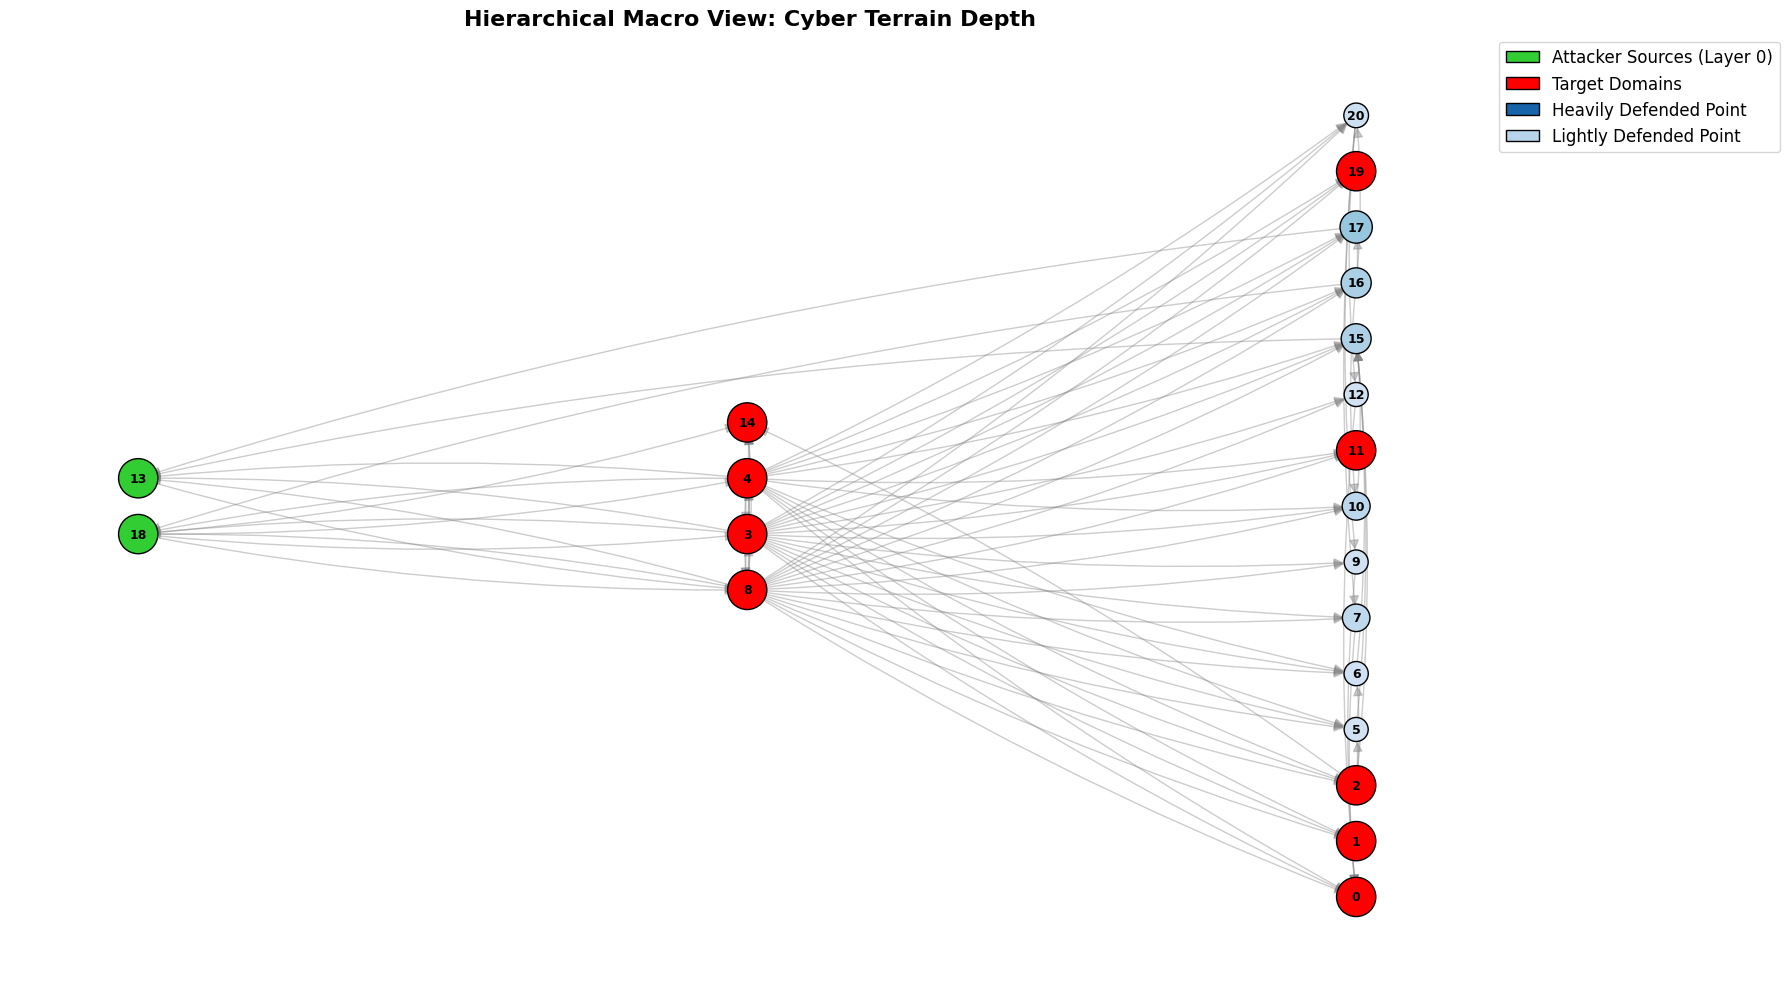


--- Analyzing threat vector from Node 13 to Node 0 ---
Path found: 13 -> 8 -> 0


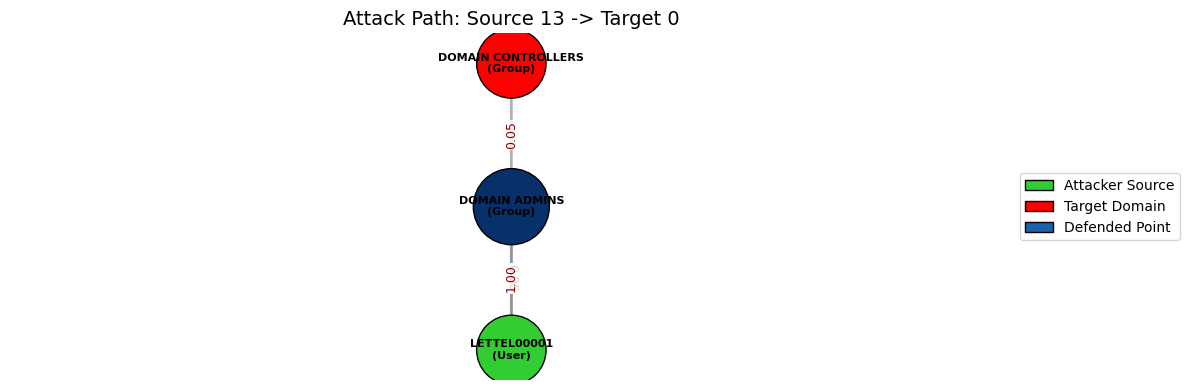


--- Analyzing threat vector from Node 13 to Node 1 ---
Path found: 13 -> 8 -> 1


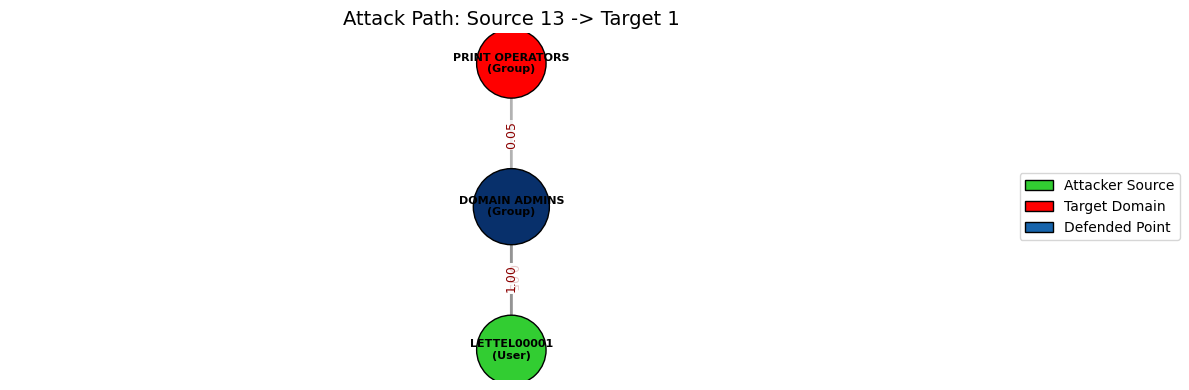


--- Analyzing threat vector from Node 13 to Node 2 ---
Path found: 13 -> 8 -> 2


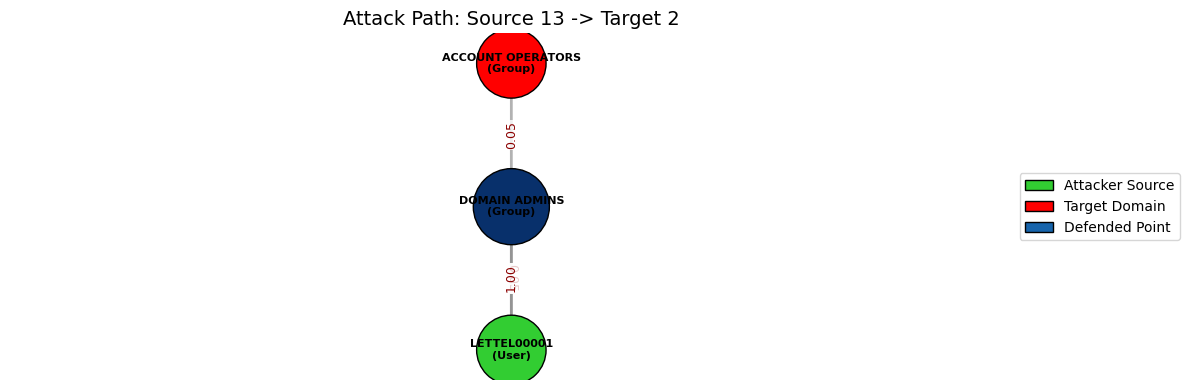


--- Analyzing threat vector from Node 13 to Node 3 ---
Path found: 13 -> 8 -> 3


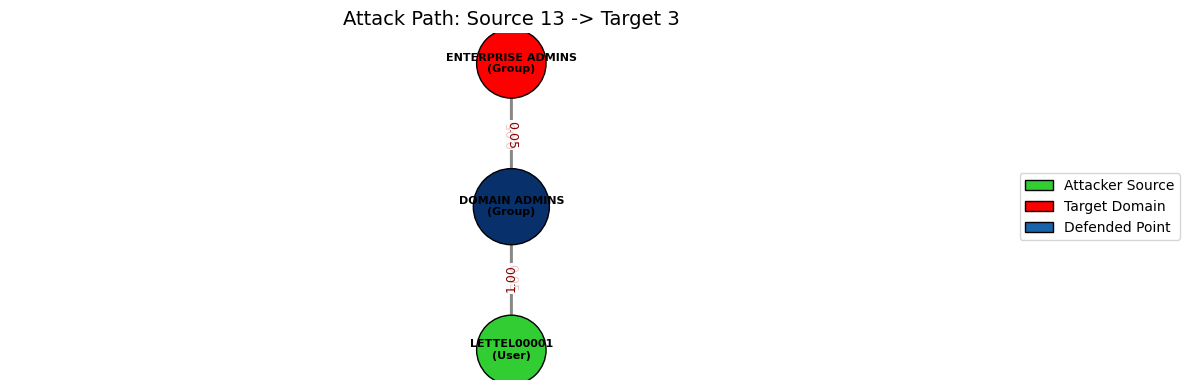


--- Analyzing threat vector from Node 13 to Node 4 ---
Path found: 13 -> 8 -> 4


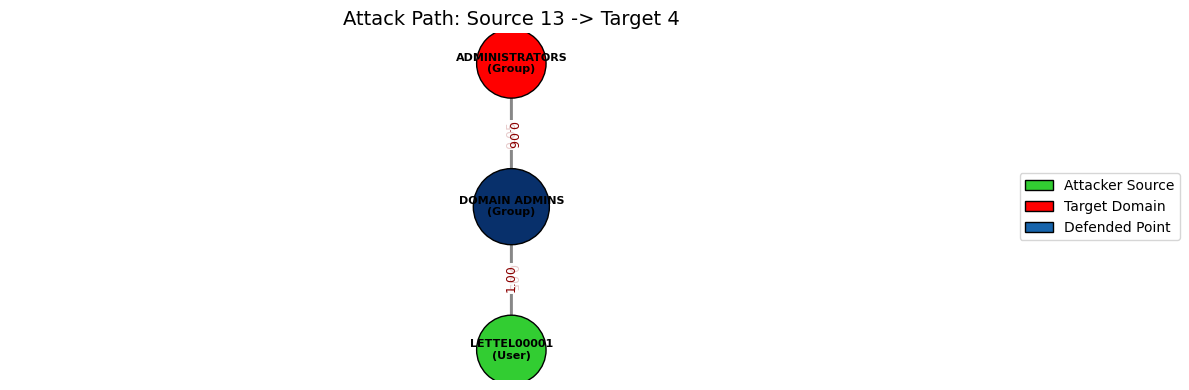


--- Analyzing threat vector from Node 13 to Node 8 ---
Path found: 13 -> 8


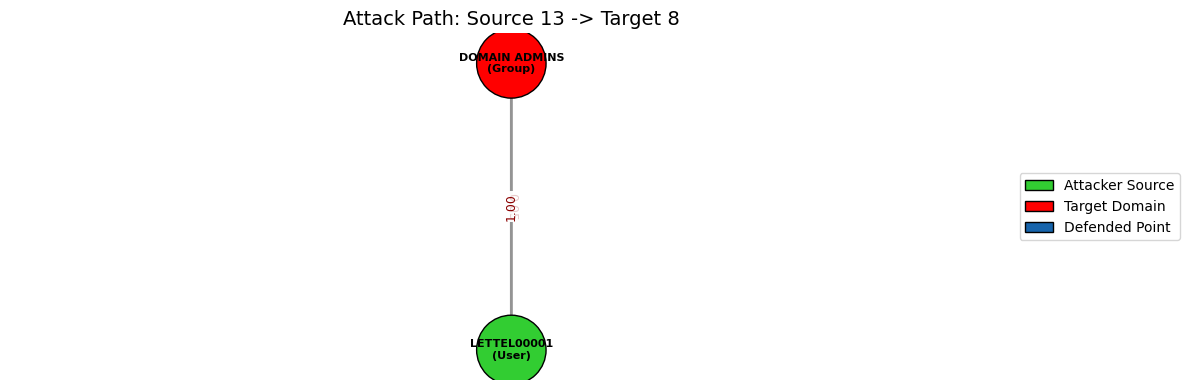


--- Analyzing threat vector from Node 13 to Node 11 ---
Path found: 13 -> 8 -> 11


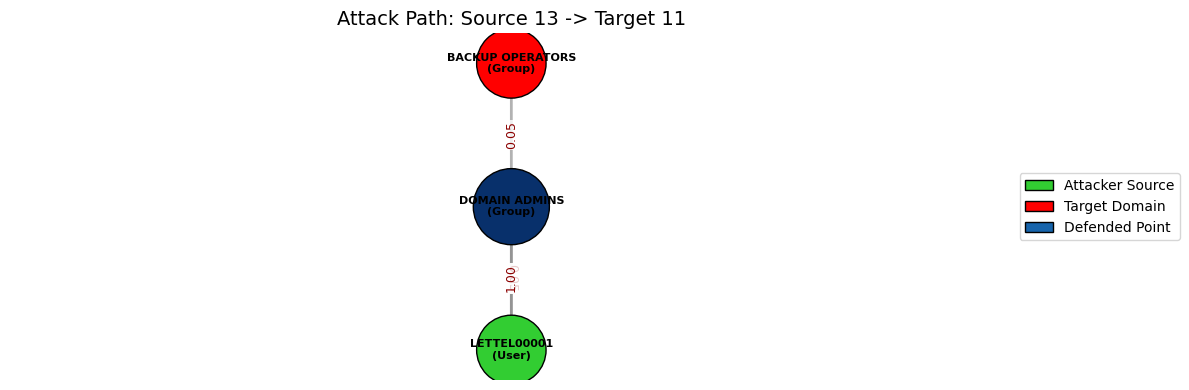


--- Analyzing threat vector from Node 13 to Node 14 ---
Path found: 13 -> 8 -> 14


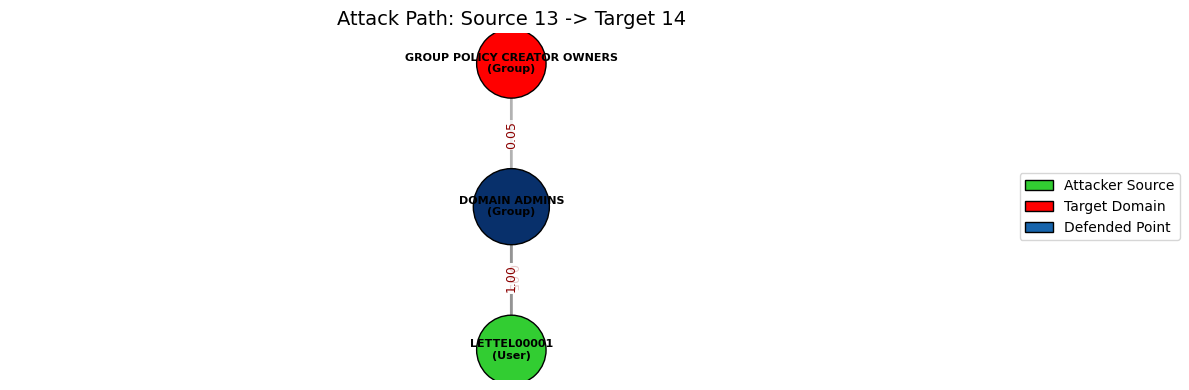


--- Analyzing threat vector from Node 13 to Node 19 ---
Path found: 13 -> 8 -> 19


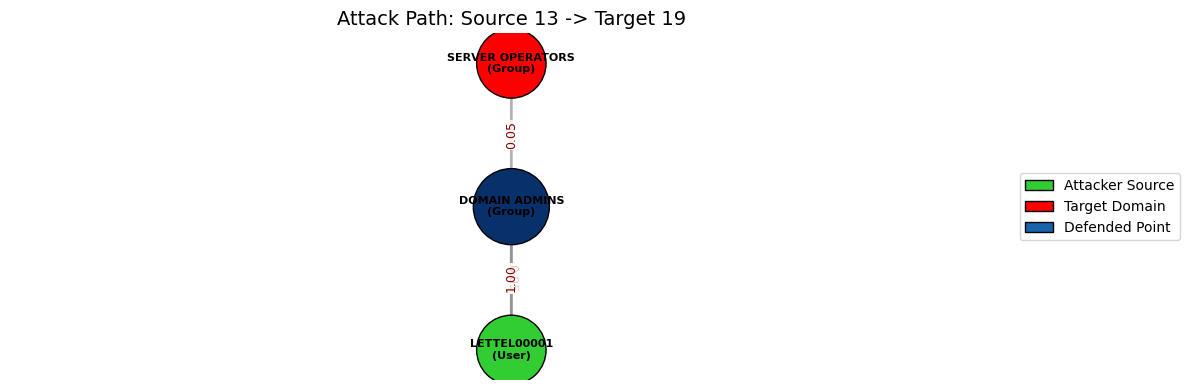


--- Analyzing threat vector from Node 18 to Node 0 ---
Path found: 18 -> 3 -> 0


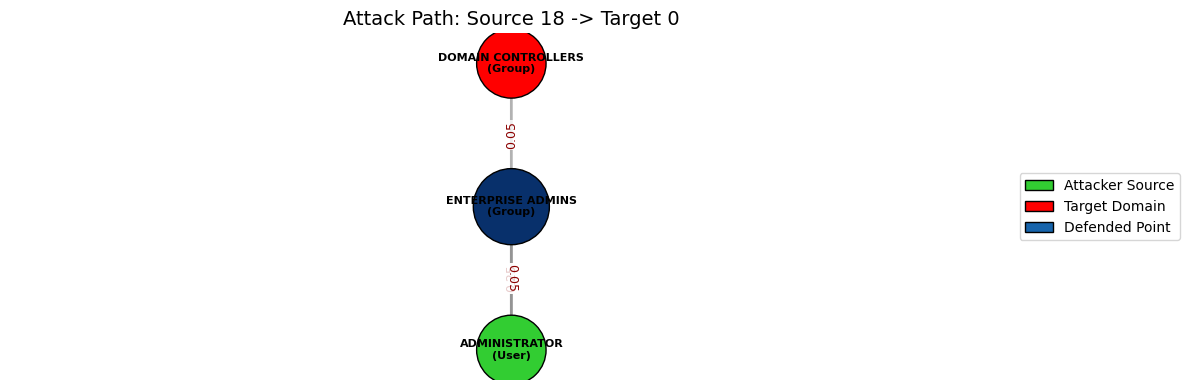


--- Analyzing threat vector from Node 18 to Node 1 ---
Path found: 18 -> 3 -> 1


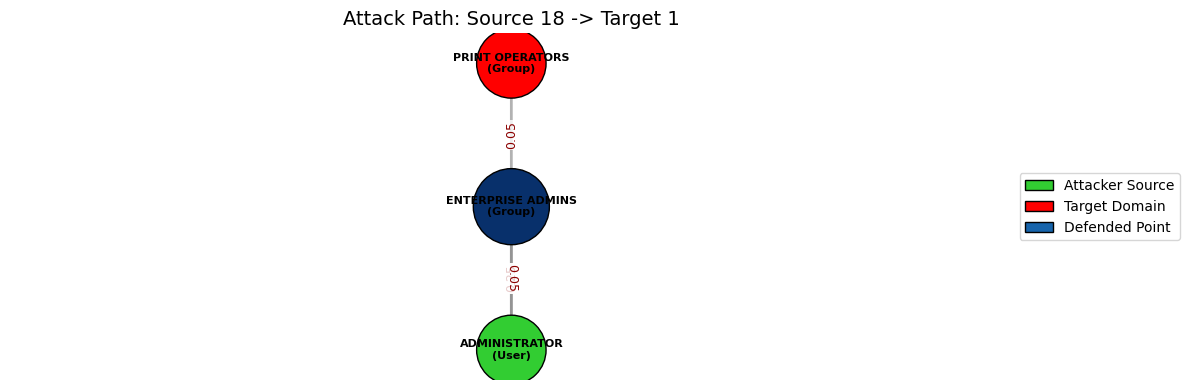


--- Analyzing threat vector from Node 18 to Node 2 ---
Path found: 18 -> 3 -> 2


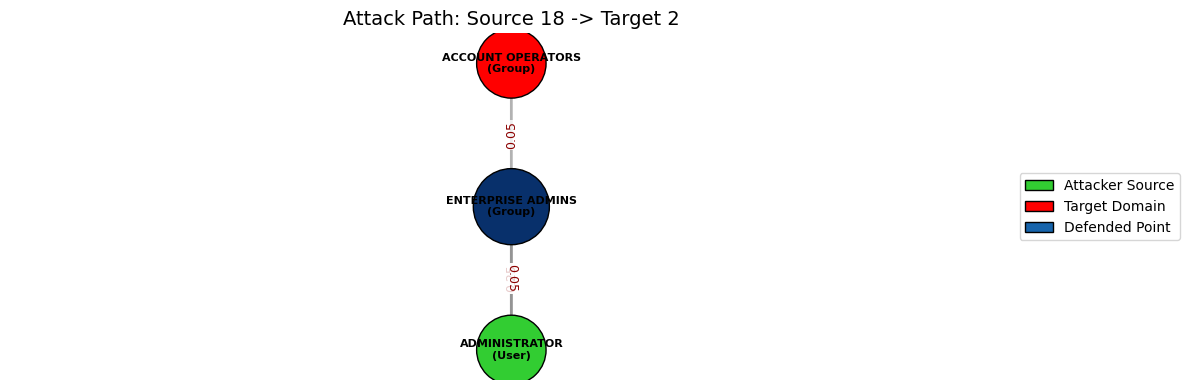


--- Analyzing threat vector from Node 18 to Node 3 ---
Path found: 18 -> 3


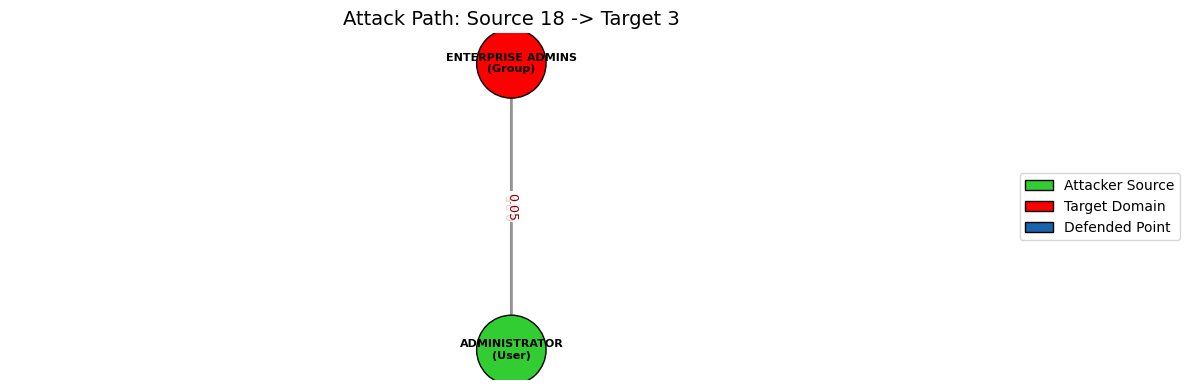


--- Analyzing threat vector from Node 18 to Node 4 ---
Path found: 18 -> 4


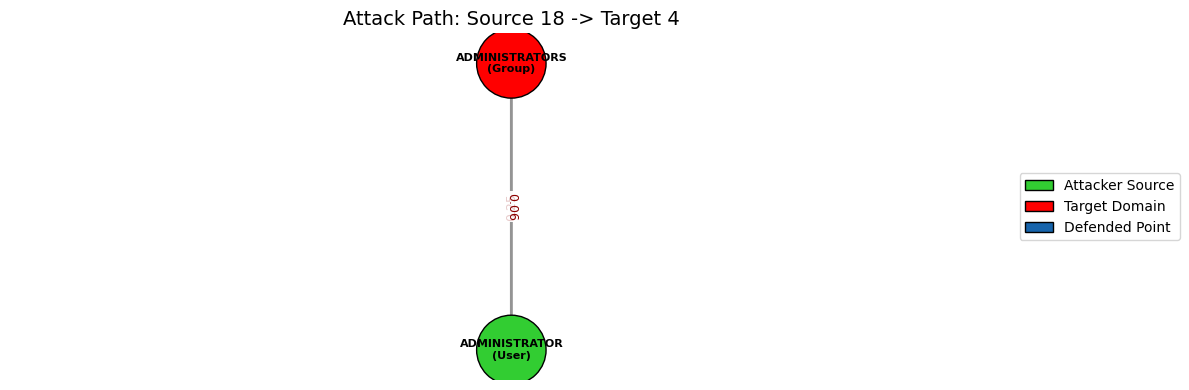


--- Analyzing threat vector from Node 18 to Node 8 ---
Path found: 18 -> 8


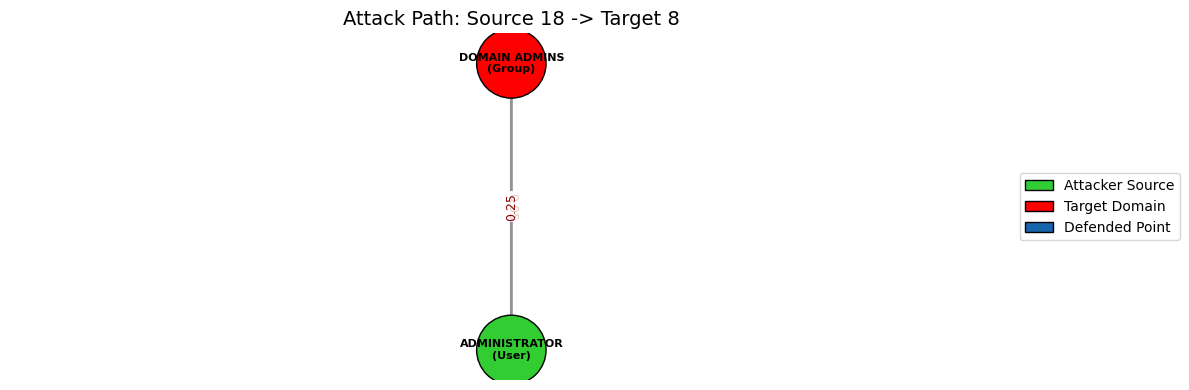


--- Analyzing threat vector from Node 18 to Node 11 ---
Path found: 18 -> 3 -> 11


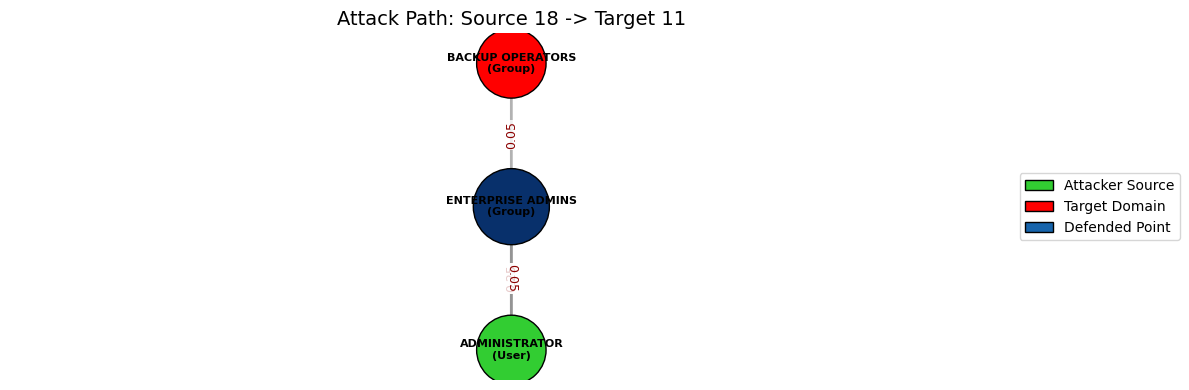


--- Analyzing threat vector from Node 18 to Node 14 ---
Path found: 18 -> 14


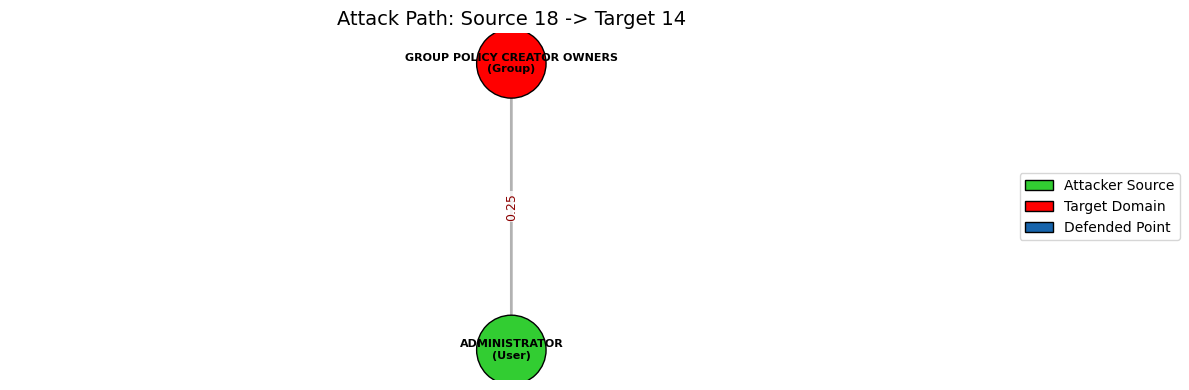


--- Analyzing threat vector from Node 18 to Node 19 ---
Path found: 18 -> 3 -> 19


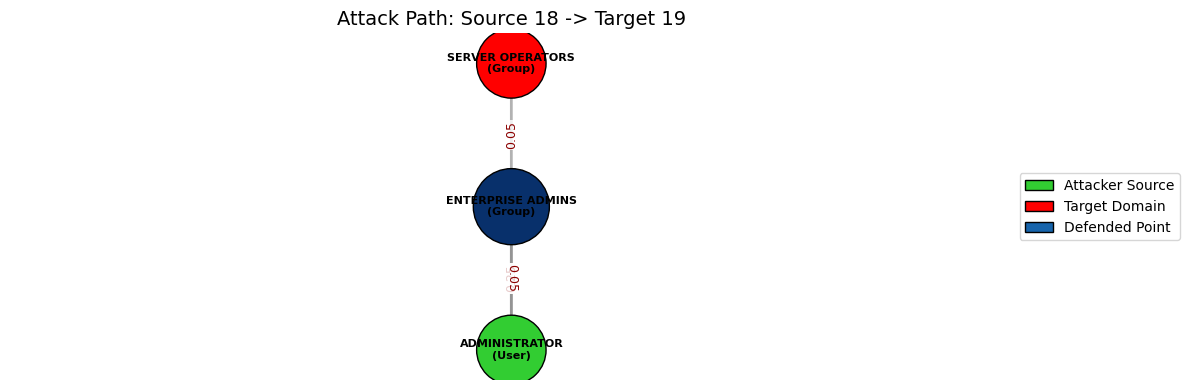

In [47]:
with open("/content/drive/MyDrive/Dataset/graph_0", 'r') as f:
    graph_data = json.load(f)
num_nodes = graph_data['metadata']['nodes_count']
edges = graph_data['subgraph_topology']['edge_index']
node_registry = graph_data['node_registry']
T = utils.build_transition_matrix(edges, num_nodes)
# Extract best known allocation for colors
actual_alloc = np.zeros(num_nodes)
for i in range(num_nodes):
    actual_alloc[i] = node_registry[str(i)].get('best_allocation_weight', 0.0)

# 2. Automatically find ALL Sources and ALL Targets
sources = [int(node_id) for node_id, data in node_registry.items() if data.get('is_source') == True]
targets = [int(node_id) for node_id, data in node_registry.items() if data.get('is_terminal') == True]

print(f"Detected {len(sources)} attacker entry points (sources) and {len(targets)} critical assets (targets).")
print(f"Total possible direct threat vectors to evaluate: {len(sources) * len(targets)}\n")

# --- PART A: Tell the story of the whole graph ---
print("Generating the Macro View of the Network...")
plot_full_network(edges, num_nodes, sources, targets, actual_alloc, node_registry)

# --- PART B: Zoom in on the specific attack paths ---
for source in sources:
    for target in targets:
        print(f"\n--- Analyzing threat vector from Node {source} to Node {target} ---")

        utils.plot_single_attack_path(
            edges=edges,
            num_nodes=num_nodes,
            source=source,
            target=target,
            allocation=actual_alloc,
            node_registry=node_registry,
            T=T
        )

## The Attacker's Dilemma: The Path of Least Resistance

In a real cyber intrusion, the network is rarely a straight line from A to B; it is a maze of interconnected systems, shared credentials, and vulnerable services.

When an attacker breaches a **Source** (🟩), they scan the environment. The algorithm might tell us the mathematically *shortest* path to the **Target** (🟥), but what if we (the defenders) have anticipated this? What if we placed all our defense budget (🟦 Dark Blue nodes) right in the middle of that shortest path?

Faced with heavy defenses (like multi-factor authentication, monitored jump servers, or strict firewalls), the attacker has a choice:
1. **The Direct Assault:** Try to brute-force or bypass the heavily defended chokepoint on the shortest path. This is noisy and has a low probability of success.
2. **The Scenic Route:** Pivot laterally. Find a secondary, slightly longer path through lightly defended, forgotten infrastructure (🟦 Light Blue nodes) to bypass the chokepoint entirely.

To truly understand our security posture, we cannot just look at a single path. We must look at the **alternative routes**. If our primary path is locked down, but a secondary path is wide open, our network is still highly vulnerable. Let's extract multiple paths to see how an attacker might pivot around our defenses.

Found 3 alternative paths from 13 to 0:
  Path 1: 13 -> 8 -> 0
  Path 2: 13 -> 8 -> 3 -> 0
  Path 3: 13 -> 8 -> 4 -> 0


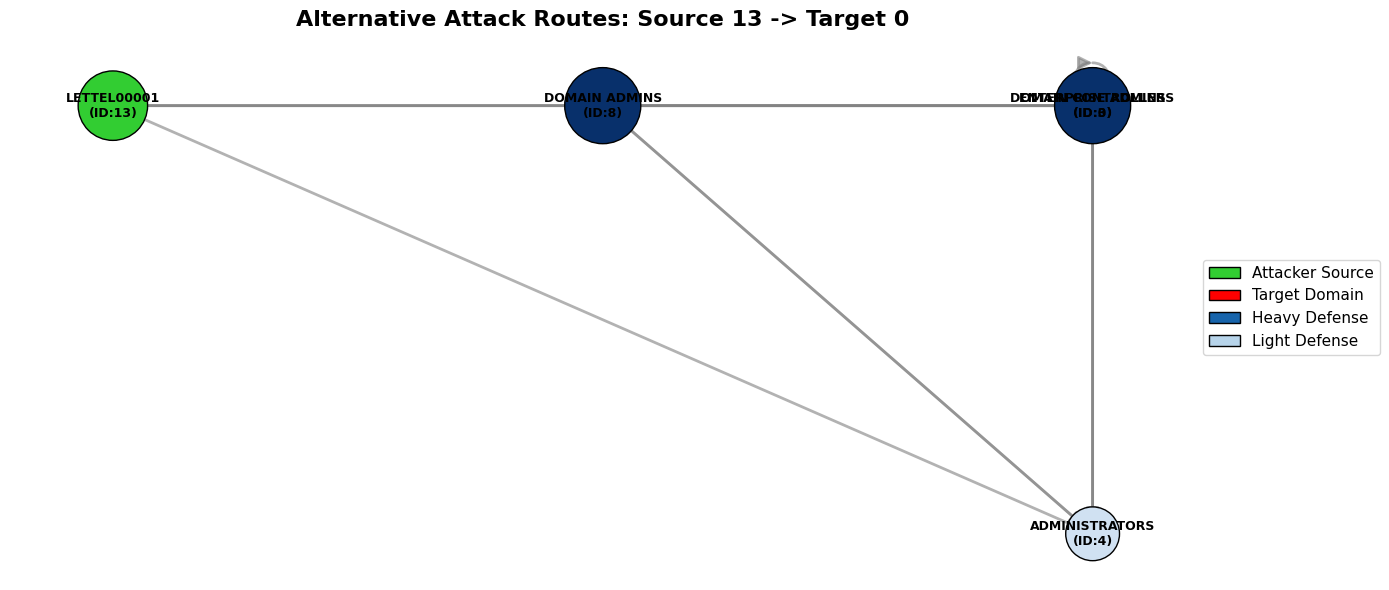

In [51]:
import itertools
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_multiple_attack_paths_clean(edges, num_nodes, source, target, allocation, node_registry=None, k=3):
    """
    Extracts top K paths and places them on a rigid X/Y grid for a clean,
    flowchart-like visualization without overlapping tangled lines.
    """
    G = nx.DiGraph()
    G.add_nodes_from(range(num_nodes))
    G.add_edges_from(edges)

    try:
        # Get the top k shortest simple paths
        paths_generator = nx.shortest_simple_paths(G, source=source, target=target)
        top_k_paths = list(itertools.islice(paths_generator, k))

        print(f"Found {len(top_k_paths)} alternative paths from {source} to {target}:")
        for i, p in enumerate(top_k_paths):
            print(f"  Path {i+1}: {' -> '.join([str(n) for n in p])}")

    except nx.NetworkXNoPath:
        print(f"No valid path found between Source {source} and Target {target}.")
        return
    except nx.NetworkXNotImplemented:
        print("Source and Target are the same node.")
        return

    # Create a subgraph containing ONLY the nodes/edges from these top K paths
    path_nodes = set(n for path in top_k_paths for n in path)
    H = G.subgraph(path_nodes).copy()

    # --- CUSTOM GRID LAYOUT ENGINE ---
    pos = {}
    # X-coordinate: Distance from source
    lengths = nx.single_source_shortest_path_length(H, source)

    # Track which path(s) each node belongs to for Y-coordinate
    node_to_path_indices = {n: [] for n in H.nodes()}
    for i, path in enumerate(top_k_paths):
        for n in path:
            node_to_path_indices[n].append(i)

    for node in H.nodes():
        x = lengths.get(node, 0)

        # Y-coordinate: Average index of the paths it belongs to.
        # Negated so Path 0 is visually at the top, Path 1 below it, etc.
        y = - (sum(node_to_path_indices[node]) / len(node_to_path_indices[node]))

        # Force Source and Target to be perfectly centered vertically
        if node == source or node == target:
            y = - (len(top_k_paths) - 1) / 2.0

        pos[node] = (x, y)
    # ---------------------------------

    # Styling
    node_colors = []
    node_sizes = []

    for node in H.nodes():
        if node == source:
            node_colors.append('limegreen')
            node_sizes.append(2500)
        elif node == target:
            node_colors.append('red')
            node_sizes.append(2500)
        else:
            budget = allocation[node]
            node_colors.append(plt.cm.Blues(0.2 + budget * 0.8))
            node_sizes.append(1500 + budget * 1500)

    # Draw the graph
    plt.figure(figsize=(14, 6))

    # We can use straighter lines now since the nodes are perfectly organized
    nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black')
    nx.draw_networkx_edges(H, pos, alpha=0.6, arrowsize=20, edge_color='gray', width=2)

    # Labels
    node_labels = {}
    for node in H.nodes():
        if node_registry is not None:
            node_data = node_registry[str(node)]
            raw_name = node_data['properties']['properties'].get('name', str(node))
            clean_name = raw_name.split('@')[0].split('.')[0]
            node_labels[node] = f"{clean_name}\n(ID:{node})"
        else:
            node_labels[node] = str(node)

    nx.draw_networkx_labels(H, pos, labels=node_labels, font_size=9, font_weight='bold', font_color='black')

    legend_elements = [
        Patch(facecolor='limegreen', edgecolor='black', label='Attacker Source'),
        Patch(facecolor='red', edgecolor='black', label='Target Domain'),
        Patch(facecolor=plt.cm.Blues(0.8), edgecolor='black', label='Heavy Defense'),
        Patch(facecolor=plt.cm.Blues(0.3), edgecolor='black', label='Light Defense')
    ]

    plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11)
    plt.title(f"Alternative Attack Routes: Source {source} -> Target {target}", fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_multiple_attack_paths_clean(edges, num_nodes, source=sources[0], target=targets[0], allocation=actual_alloc, node_registry=node_registry, k=3)